In [1]:
from pathlib import Path
from obspy import read
import numpy as np
data_path = Path("/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_500Hz")
file_list = sorted(data_path.glob("*.miniseed"))
print(f"Found {len(file_list)} miniseed files")
for file in file_list[0:3]:
    print(file)
    st = read(str(file))#, headonly=True)
    print(st)
    
    tr = st[0]

    print(tr)
    print(tr.data.dtype)
    print(np.all(tr.data == np.round(tr.data)))
    print(tr.data[:20])
    

Found 165 miniseed files
/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_500Hz/453005726.0001.2026.05.17.16.00.00.000.E.miniseed
1 Trace(s) in Stream:
SS.05726.SW.DPE | 2026-05-17T16:00:00.000000Z - 2026-05-18T16:00:00.000000Z | 500.0 Hz, 43200001 samples
SS.05726.SW.DPE | 2026-05-17T16:00:00.000000Z - 2026-05-18T16:00:00.000000Z | 500.0 Hz, 43200001 samples
float32
False
[-0.00476837 -0.00745058 -0.00566244 -0.00506639 -0.00625849 -0.00298023
 -0.00298023 -0.00357628 -0.00476837 -0.00655651 -0.00506639 -0.00447035
 -0.00596046 -0.00685453 -0.00596046 -0.00655651 -0.00804663 -0.0077486
 -0.00953674 -0.00923872]
/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_500Hz/453005726.0001.2026.05.17.16.00.00.000.N.miniseed
1 Trace(s) in Stream:
SS.05726.SW.DPN | 2026-05-17T16:00:00.000000Z - 2026-05-18T16:00:00.000000Z | 500.0 Hz, 43200001 samples
SS.05726.SW.DPN | 2026-05-17T16:00:00.000000Z - 2026-05-18T16:00:00.

In [2]:
from obspy.clients.filesystem.sds import Client
from obspy import UTCDateTime
sds_client = Client("/Volumes/tachyon/LBSSP_DATA/nodal_sds")
stime = UTCDateTime(2026,5,18,0,0,0)
st = sds_client.get_waveforms(network="T1", station="*", location="N*", channel="*Z", starttime=stime, endtime=stime + 86400)
print(st)

24 Trace(s) in Stream:

T1.05726.N2.DPZ | 2026-05-18T00:00:00.000000Z - 2026-05-19T00:00:00.000000Z | 500.0 Hz, 43200001 samples
...
(22 other traces)
...
T1.20358.N2.DPZ | 2026-05-18T00:00:00.000000Z - 2026-05-19T00:00:00.000000Z | 500.0 Hz, 43200001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


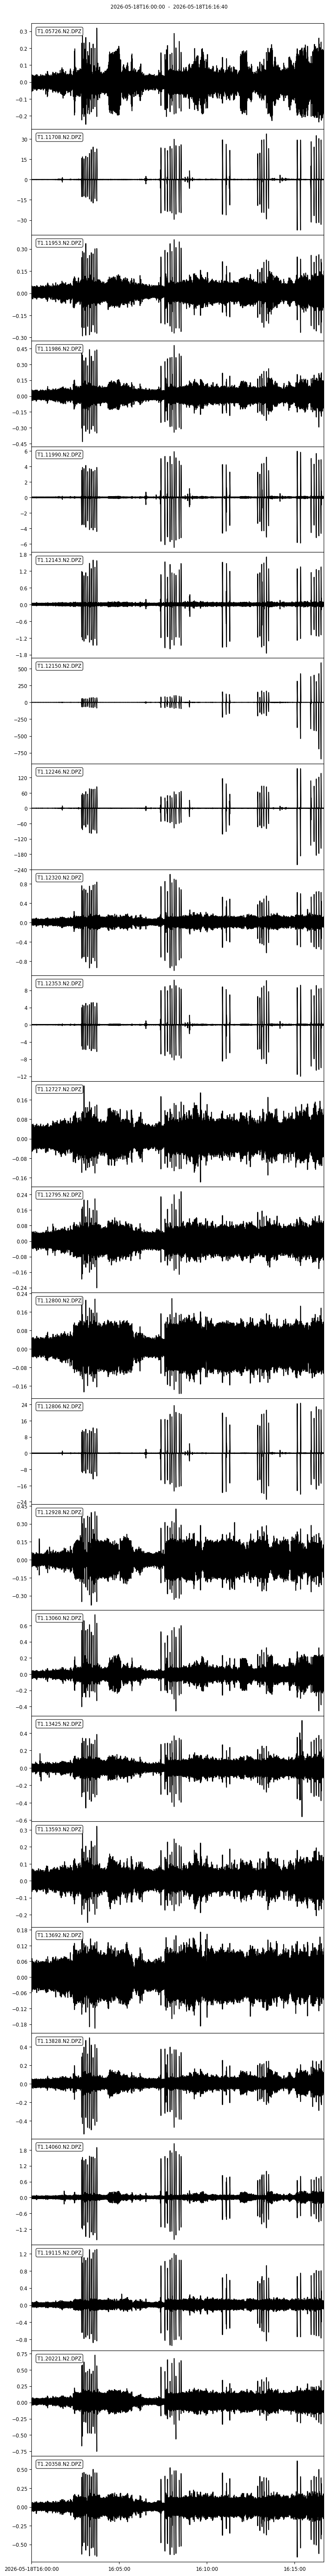

In [3]:
st.select(component="Z").plot(equal_scale=False, starttime=stime+16*3600, endtime=stime + 16*3600+1000);

In [8]:
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy import UTCDateTime

client = EnhancedSDSClient("/Volumes/tachyon/LBSSP_DATA/nodal_sds")
t = UTCDateTime("2026-05-17T16:00:00")
st = client.get_waveforms("T1", "*", "N2", "DPZ", t-86400, t+86400*3)
print(st)
st.plot(equal_scale=False, outfile="test_plot.png")

31 Trace(s) in Stream:

T1.05726.N2.DPZ | 2026-05-17T16:00:00.000000Z - 2026-05-19T13:20:00.000000Z | 500.0 Hz, 81600001 samples
...
(29 other traces)
...
T1.20358.N2.DPZ | 2026-05-17T16:56:58.000000Z - 2026-05-19T13:20:00.000000Z | 500.0 Hz, 79891001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
